# Data Ingestion

This notebook demonstrates `portfolio.data.DataIngestion`, a thin wrapper around `yfinance.download` that pulls closing prices for every ticker declared in `portfolio.config` and produces clean, tidy DataFrames ready for the rest of the library.

We will:

1. Fetch prices for each asset class.
2. Run **exploratory data analysis (EDA)** on the resulting DataFrame — shape, missing values, summary statistics.
3. Visualise price levels and return distributions.
4. Show how `compute_returns` turns prices into returns.

## 1. Setup

`DataIngestion` takes optional `start_date` and `end_date` arguments; when omitted, it falls back to the values in `portfolio.config`.

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns

from portfolio.data import DataIngestion

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)

ingestion = DataIngestion()
f"window: {ingestion.start_date} → {ingestion.end_date}"

'window: 2022-12-01 → 2026-04-30'

## 2. Fetching prices

Each `get_*_prices` method returns a DataFrame indexed by date with one column per ticker. Tickers are sorted alphabetically and rows containing NaN values are dropped.

In [2]:
stock_prices = ingestion.get_stock_prices()
stock_prices.tail()

Ticker,AAL,AAPL,ADBE,AMD,AMZN,AVGO,BA,BAC,CAT,CCL,...,SNAP,SOFI,T,TGT,TSLA,V,VZ,WFC,WMT,XOM
Date,,,,,,,,,,,,,,,,,,,,,
2026-04-23,11.78,273.429993,238.979996,305.329987,255.080002,419.940002,234.149994,52.470001,835.239990,26.650000,...,5.57,18.320000,26.610001,130.169998,373.720001,308.880005,47.220001,80.510002,132.029999,150.529999
2026-04-24,12.10,271.059998,245.440002,347.809998,263.989990,422.760010,232.440002,52.049999,830.789978,27.170000,...,5.65,18.440001,26.200001,129.259995,376.299988,309.420013,46.380001,79.419998,129.919998,148.910004
2026-04-27,11.68,267.609985,239.309998,334.630005,261.119995,418.200012,231.330002,52.630001,828.789978,26.770000,...,6.06,18.760000,25.520000,129.720001,378.670013,309.649994,47.099998,80.559998,127.589996,148.190002
2026-04-28,11.64,270.709991,243.199997,323.209991,259.700012,399.829987,230.720001,52.660000,817.869995,26.299999,...,5.95,18.360001,26.059999,127.139999,376.019989,309.299988,47.240002,81.500000,127.589996,150.559998
2026-04-29,11.31,270.170013,243.570007,337.109985,263.040009,405.450012,224.110001,52.880001,810.049988,25.580000,...,5.98,15.525000,25.750000,127.870003,372.799988,334.859985,46.610001,81.510002,128.009995,154.669998


## 3. EDA — shape, missingness, summary stats

Before modelling anything, it pays to confirm the data is what you expect. The four checks below catch the vast majority of ingestion-time problems (missing dates, dtype mismatches, constant columns, suspicious outliers).

In [3]:
print(f"shape:           {stock_prices.shape}")
print(f"date range:      {stock_prices.index.min().date()} → {stock_prices.index.max().date()}")
print(f"missing values:  {int(stock_prices.isna().sum().sum())}")
print(f"unique dtypes:   {stock_prices.dtypes.unique().tolist()}")

shape:           (854, 52)
date range:      2022-12-01 → 2026-04-29
missing values:  0
unique dtypes:   [dtype('float64')]


In [4]:
stock_prices.describe().T.head(10)

,count,mean,std,min,25%,50%,75%,max
Ticker,,,,,,,,
AAL,854.0,13.456089,2.130623,9.070000,11.597500,13.430000,14.867500,18.799999
AAPL,854.0,207.811756,37.713557,125.019997,178.625000,203.310005,235.044998,286.190002
ADBE,854.0,435.352540,101.673169,225.350006,350.950005,435.879990,521.177505,634.760010
AMD,854.0,144.587400,49.080518,62.330002,107.605000,138.714996,170.869995,347.809998
AMZN,854.0,177.282729,46.257687,81.820000,137.715000,185.004997,217.492500,263.989990
AVGO,854.0,182.174831,102.255301,51.849998,88.891750,162.209999,263.097488,422.760010
BA,854.0,198.717026,25.805329,136.589996,179.564995,201.705002,215.985001,264.269989
BAC,854.0,39.904286,8.536533,25.170000,32.750000,39.615000,46.840000,57.250000
CAT,854.0,372.740526,141.847432,205.750000,270.347511,342.229996,401.392494,835.239990


## 4. Visualising price levels

Plotting raw price levels shows the rough scale and trend of each asset, but levels are not directly comparable across tickers (a stock at \$5 and one at \$500 say nothing about relative performance). Normalising every series to start at 1 makes the comparison fair.

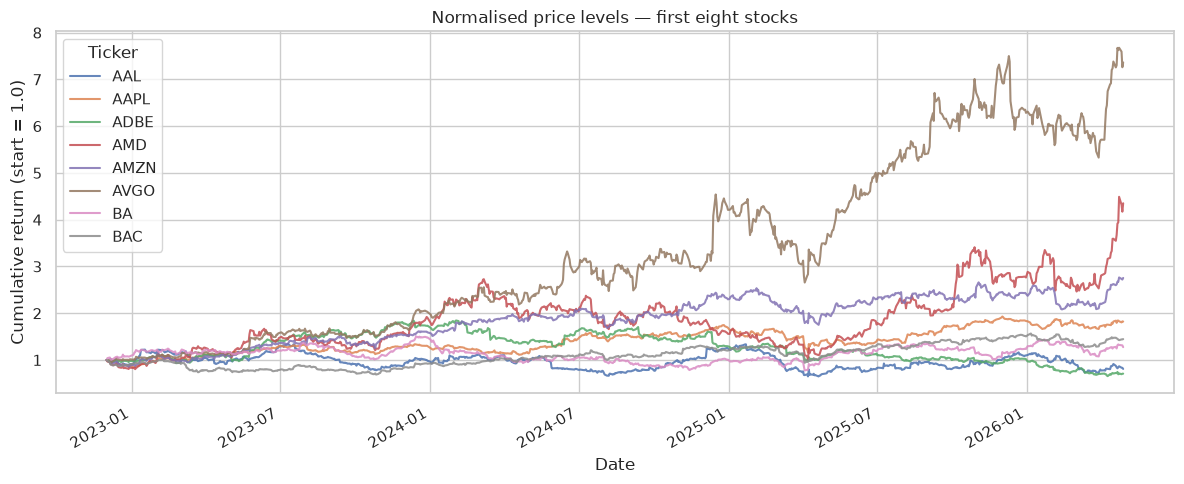

In [5]:
normalised = stock_prices / stock_prices.iloc[0]

fig, ax = plt.subplots()
normalised.iloc[:, :8].plot(ax=ax, alpha=0.85)
ax.set_title("Normalised price levels — first eight stocks")
ax.set_ylabel("Cumulative return (start = 1.0)")
ax.set_xlabel("Date")
fig.tight_layout()
plt.show()

## 5. Computing returns

`DataIngestion.compute_returns` applies `pct_change` and drops the leading NaN row. It is a static method, so you can pass it any price DataFrame — including one you loaded from disk.

In [6]:
stock_returns = DataIngestion.compute_returns(stock_prices)
stock_returns.tail()

Ticker,AAL,AAPL,ADBE,AMD,AMZN,AVGO,BA,BAC,CAT,CCL,...,SNAP,SOFI,T,TGT,TSLA,V,VZ,WFC,WMT,XOM
Date,,,,,,,,,,,,,,,,,,,,,
2026-04-23,0.024348,0.000952,-0.066266,0.006162,-0.001096,-0.006412,0.012409,-0.012236,0.032601,-0.010765,...,-0.046233,-0.038825,0.024249,-0.003293,-0.035586,-0.007742,0.026968,-0.000869,0.015772,0.006890
2026-04-24,0.027165,-0.008668,0.027032,0.139128,0.034930,0.006715,-0.007303,-0.008005,-0.005328,0.019512,...,0.014363,0.006550,-0.015408,-0.006991,0.006904,0.001748,-0.017789,-0.013539,-0.015981,-0.010762
2026-04-27,-0.034711,-0.012728,-0.024976,-0.037894,-0.010872,-0.010786,-0.004775,0.011143,-0.002407,-0.014722,...,0.072566,0.017354,-0.025954,0.003559,0.006298,0.000743,0.015524,0.014354,-0.017934,-0.004835
2026-04-28,-0.003425,0.011584,0.016255,-0.034127,-0.005438,-0.043926,-0.002637,0.000570,-0.013176,-0.017557,...,-0.018152,-0.021322,0.021160,-0.019889,-0.006998,-0.001130,0.002972,0.011668,0.000000,0.015993
2026-04-29,-0.028351,-0.001995,0.001521,0.043006,0.012861,0.014056,-0.028649,0.004178,-0.009561,-0.027376,...,0.005042,-0.154412,-0.011896,0.005742,-0.008563,0.082638,-0.013336,0.000123,0.003292,0.027298


### Distribution of daily returns

Daily returns are the input to every model in this repository. A quick histogram shows the central peak around zero and the fat tails that motivate VaR / CVaR.

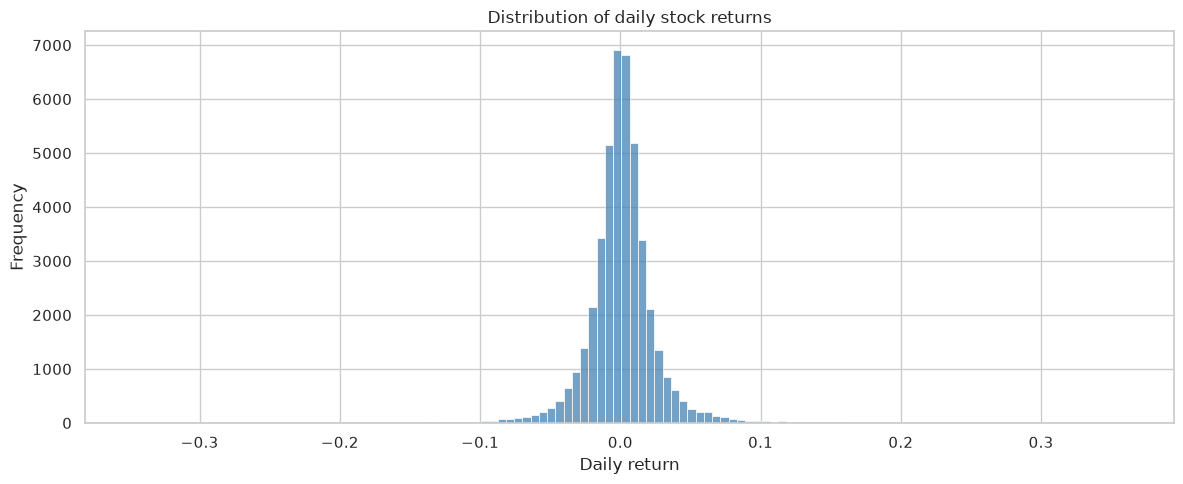

In [7]:
fig, ax = plt.subplots()
sns.histplot(stock_returns.stack(), bins=120, ax=ax, color="steelblue")
ax.set_title("Distribution of daily stock returns")
ax.set_xlabel("Daily return")
ax.set_ylabel("Frequency")
fig.tight_layout()
plt.show()

### Correlation structure

A correlation heatmap surfaces clusters of co-moving assets. These clusters matter for portfolio construction: the diversification benefit comes from combining assets with low (or negative) correlations.

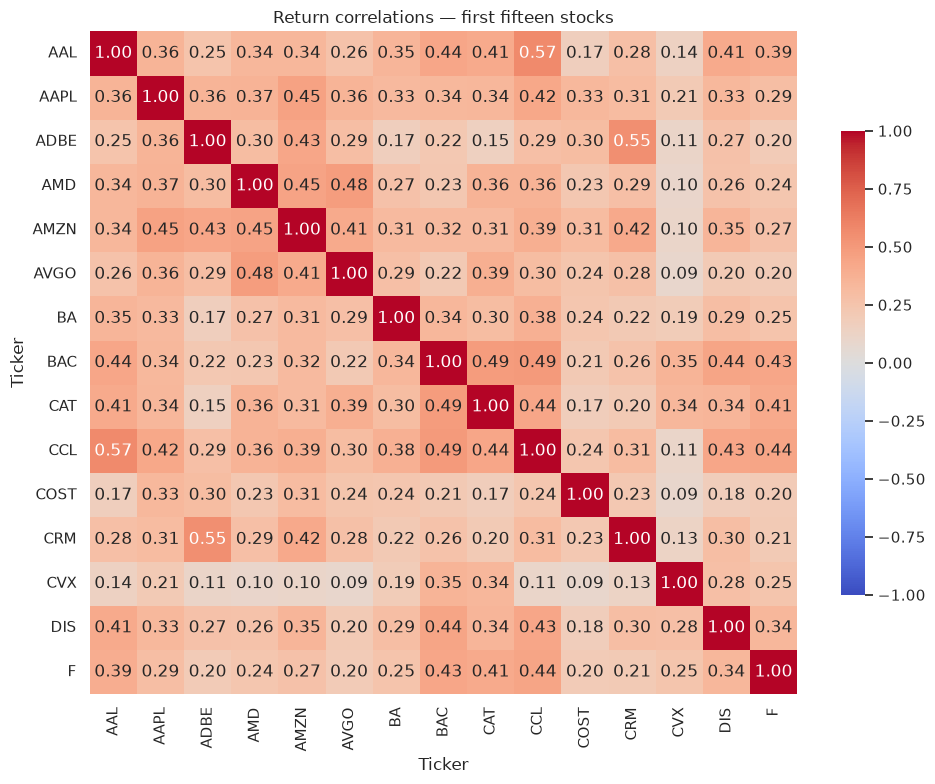

In [8]:
subset = stock_returns.iloc[:, :15]
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    subset.corr(),
    cmap="coolwarm",
    center=0,
    vmin=-1, vmax=1,
    annot=True, fmt=".2f",
    cbar_kws={"shrink": 0.7},
    ax=ax,
)
ax.set_title("Return correlations — first fifteen stocks")
fig.tight_layout()
plt.show()

## 6. Other asset classes

The remaining helpers (`get_etf_prices`, `get_bond_prices`, `get_crypto_prices`, `get_sp500_prices`) work the same way. `get_all_prices` returns the entire universe in one DataFrame.

In [9]:
ingestion.get_bond_prices().tail()

Ticker,^FVX,^IRX,^TNX,^TYX
Date,,,,
2026-04-23,3.952,3.595,4.323,4.918
2026-04-24,3.920,3.593,4.310,4.916
2026-04-27,3.947,3.590,4.336,4.942
2026-04-28,3.983,3.590,4.354,4.944
2026-04-29,4.065,3.590,4.418,4.987


In [10]:
ingestion.get_crypto_prices().tail()

Ticker,ADA-USD,BNB-USD,BTC-USD,DOGE-USD,ETH-USD,LINK-USD,SOL-USD,TRX-USD,USDC-USD,USDT-USD,XRP-USD,ZEC-USD
Date,,,,,,,,,,,,
2026-04-25,0.250270,628.657288,77612.015625,0.098048,2318.829102,9.346175,86.151176,0.324008,0.999733,1.000167,1.424219,359.027161
2026-04-26,0.252328,636.111450,78657.539062,0.099289,2369.729004,9.494079,86.970383,0.323531,0.999955,1.000292,1.431575,355.121796
2026-04-27,0.248151,626.964233,77366.625000,0.098978,2303.063965,9.320954,84.817787,0.325239,0.999820,0.999889,1.400906,355.729797
2026-04-28,0.246805,624.311035,76350.671875,0.099379,2289.419678,9.239625,84.038979,0.323010,0.999953,0.999902,1.380665,335.626892
2026-04-29,0.244517,617.329773,75776.132812,0.104018,2253.415771,9.118187,83.026871,0.323058,0.999785,0.999559,1.369252,327.354279


In [11]:
ingestion.get_all_prices().shape

(299, 102)